In [1]:
import os
from typing import TypedDict, Optional

from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage  # adjust import path if needed
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

# 1. LLM setup
def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=2000
    )

llm = get_groq_llm()

In [2]:


# 2. Define State schema
class PostState(TypedDict, total=False):
    info: dict                     # input information for the post (topic, tone, audience, key points, etc)
    draft: str                     # current draft of LinkedIn post
    human_feedback: Optional[str]  # feedback from human reviewer
    approved: bool                 # whether human reviewer approved
    final_post: Optional[str]      # final approved post content


In [3]:

# 3. Node: Generate initial draft
def generate_draft(state: PostState) -> dict:
    info = state["info"]
    # Build prompt based on info
    prompt = f"""You are writing a LinkedIn post. Here is the info:
Topic: {info.get('topic')}
Key points: {info.get('key_points')}
Tone: {info.get('tone')}
Audience: {info.get('audience')}

Write a LinkedIn-style post (1-2 short paragraphs) with that info."""
    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content.strip()
    print("=== AI Generated Draft ===")
    print(draft)
    return {"draft": draft, "approved": False}

# 4. Node: Ask human reviewer for feedback/approval
def ask_for_feedback(state: PostState) -> dict:
    print("\n--- PAUSING FOR HUMAN REVIEW ---")
    print("Draft to review:")
    print(state["draft"])
    # Use interrupt to pause and wait for human input
    feedback = interrupt("Please review the draft. Provide feedback (or type 'approved' if OK):")
    # Determine approval based on exact word (you may refine logic)
    approved = (feedback.strip().lower() == "approved")
    return {"human_feedback": feedback, "approved": approved}

# 5. Node: Decide next step
# def decide_next(state: PostState) -> Command:
#     if state.get("approved"):
#         return Command(goto="post_to_linkedin")
#     else:
#         return Command(goto="revise_draft")


def decide_next(state: PostState) -> str:
    if state.get("approved", False):
        return "approved"
    else:
        return "revise"


# 6. Node: Revise draft based on feedback
def revise_draft(state: PostState) -> dict:
    feedback = state["human_feedback"] or ""
    old_draft = state["draft"]
    prompt = f"""You are rewriting a LinkedIn post. Original draft:
{old_draft}

Feedback from reviewer:
{feedback}

Revise the draft accordingly (keeping same tone and audience) and output the improved post."""
    response = llm.invoke([HumanMessage(content=prompt)])
    new_draft = response.content.strip()
    print("=== AI Revised Draft ===")
    print(new_draft)
    return {"draft": new_draft, "approved": False}

# 7. Node: Post to LinkedIn (stub)
def post_to_linkedin(state: PostState) -> dict:
    final = state["draft"]
    # Here you would make the real LinkedIn API call.
    # e.g. linkedin_client.post_update(final)
    print("=== POSTING TO LINKEDIN ===")
    print(final)
    # After posting, you can set final_post
    return {"final_post": final}



In [4]:
# 8. Build the workflow graph
def build_workflow_graph() -> StateGraph:
    builder = StateGraph(PostState)

    builder.add_node("generate_draft", generate_draft)
    builder.add_node("ask_for_feedback", ask_for_feedback)
    builder.add_node("revise_draft", revise_draft)
    builder.add_node("post_to_linkedin", post_to_linkedin)

    # Define edges
    builder.add_edge(START, "generate_draft")
    # builder.add_edge("generate_draft", "ask_for_feedback")
    # builder.add_conditional_edges('ask_for_feedback', decide_next, {'approved': 'post_to_linkedin', 'needs_improvement': 'revise_draft'})
    # builder.add_edge('revise_draft', 'ask_for_feedback')
    # builder.add_edge("post_to_linkedin", END)

    builder.add_edge("generate_draft", "ask_for_feedback")
    builder.add_conditional_edges(
        "ask_for_feedback",
        decide_next,
        {"approved": "post_to_linkedin", "revise": "revise_draft"}
    )
    builder.add_edge("revise_draft", "ask_for_feedback")
    builder.add_edge("post_to_linkedin", END)

    # Compile with checkpointing to support interrupt/resume
    graph = builder.compile(checkpointer=InMemorySaver())
    return graph



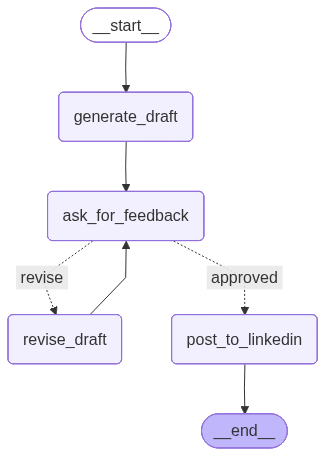

In [5]:
graph= build_workflow_graph()
graph

In [6]:
# 9. Usage / Execution
if __name__ == "__main__":
    # Example input info
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = {"configurable": {"thread_id": thread_id}}

    # Start workflow
    result = graph.invoke(initial_state, config=config)
    # When it hits interrupt (in ask_for_feedback), you'll need to resume manually:
    # For example:
    #   graph.invoke(Command(resume="Looks great, approve"), config=config)
    #
    # In a real UI setup you'd capture human input & call resume programmatically.

    print("\nWorkflow ended. Final state:")
    print(graph.get_state(config))


=== AI Generated Draft ===
🚀 **Data Science Workflow Automation with LangGraph**  
At [Your Brand], we’re turning the traditional data‑science pipeline into a *true agentic workflow*—where each step can autonomously decide the next action, yet still invites a human in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.

🔍 **Why it matters for you**  
When your analytics stack can self‑direct, you free up time to dive deeper into insights and strategy. Plus, the same modular approach is perfect for creating bite‑size, shareable LinkedIn posts that walk peers through the workflow, showcasing reproducibility and best practices. Let’s keep the conversation going—drop a comment if you’ve tried LangGraph or want to see a quick demo of a human‑in‑the‑loop data‑science loop!

--- PAUSING

In [7]:
print(graph.get_state(config))

StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Data Science Workflow Automation with LangGraph**  \nAt [Your Brand], we’re turning the traditional data‑science pipeline into a *true agentic workflow*—where each step can autonomously decide the next action, yet still invites a human in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.\n\n🔍 **Why it matters for you**  \nWhen your analytics stack can self‑direct, you free up time to dive deeper into insights and strategy. Plus, the same modular approach is perfect for creating bite‑size, share

## Manual resume:

In [8]:
# Step 2: Pause at human review
state = graph.get_state(config)
interrupts = getattr(state, "interrupts", None) or []
if not interrupts:
    print("⚠️ Unexpected: no interrupt was raised for human review.")
else:
    for intr in interrupts:
        print(f"Interrupt ID: {intr.id}, prompt: {intr.value}")

    # Ask human for feedback
    human_answer = input("Enter feedback or type ‘approve’: ")

    # Step 3: Resume workflow with human feedback
    result2 = graph.invoke(Command(resume={interrupts[0].id: human_answer}), config=config)
    print("=== After resume with human feedback ===")
    print(graph.get_state(config))



Interrupt ID: e18c1a4d1429058a905bfb2f42a9a0d3, prompt: Please review the draft. Provide feedback (or type 'approved' if OK):

--- PAUSING FOR HUMAN REVIEW ---
Draft to review:
🚀 **Data Science Workflow Automation with LangGraph**  
At [Your Brand], we’re turning the traditional data‑science pipeline into a *true agentic workflow*—where each step can autonomously decide the next action, yet still invites a human in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.

🔍 **Why it matters for you**  
When your analytics stack can self‑direct, you free up time to dive deeper into insights and strategy. Plus, the same modular approach is perfect for creating bite‑size, shareable LinkedIn posts that walk peers through the workflow, showcasing reproducibility and best practices. Let’s k

In [9]:
# Step 4: Check if approved. If not, ask human for next step or loop.
final_state = graph.get_state(config)
print("\n--- Final State Check ---")
print(final_state)



--- Final State Check ---
StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Data Science & Engineering Workflow Automation with LangGraph**  \nAt **[Your Brand]**, we’re turning the entire data‑science pipeline into a *true agentic workflow*—where every step can autonomously decide its next move while still inviting a human (or a data engineer) in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.\n\n🔍 **Why it matters for you**  \nWhen your analytics stack can self‑direct, data scientists free up time to dive deeper into insights and strategy

In [10]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Data Science & Engineering Workflow Automation with LangGraph**  \nAt **[Your Brand]**, we’re turning the entire data‑science pipeline into a *true agentic workflow*—where every step can autonomously decide its next move while still inviting a human (or a data engineer) in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.\n\n🔍 **Why it matters for you**  \nWhen your analytics stack can self‑direct, data scientists free up time to dive deeper into insights and strategy, while data engineers can

In [11]:
# Feedback you got from human
feedback_value = "approved"

# Use the interrupt ID from the snapshot: e.g., "527d0f000978e04a698659d87dddb60d"
resume_command = Command(resume={ "54decab71cdd215a7bf4fcbb311c8bcc": feedback_value })

# Invoke the graph to resume
result = graph.invoke(resume_command, config=config)

# Then check the updated state
state_after = graph.get_state(config)
print("State after resuming:", state_after)



--- PAUSING FOR HUMAN REVIEW ---
Draft to review:
🚀 **Data Science & Engineering Workflow Automation with LangGraph**  
At **[Your Brand]**, we’re turning the entire data‑science pipeline into a *true agentic workflow*—where every step can autonomously decide its next move while still inviting a human (or a data engineer) in the loop for oversight and sanity checks. LangGraph lets you stitch together modular, state‑driven agents that learn from your data, your code, and your feedback. The result? Faster experiments, fewer bottlenecks, and a safety net that keeps your models honest.

🔍 **Why it matters for you**  
When your analytics stack can self‑direct, data scientists free up time to dive deeper into insights and strategy, while data engineers can focus on scaling, data quality, and orchestration. The same modular approach is perfect for creating bite‑size, shareable LinkedIn posts that walk peers through the workflow, showcasing reproducibility and best practices.  

Let’s keep th

## Automatic Loop Resume:

In [12]:
# 9. Automatic loop execution
if __name__ == "__main__":
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = {"configurable": {"thread_id": thread_id}}

    # Invoke the workflow
    graph.invoke(initial_state, config=config)

    # Loop for human input until workflow ends
    while True:
        state = graph.get_state(config)
        interrupts = getattr(state, "interrupts", None) or []
        if not interrupts:
            # Workflow done
            break

        for intr in interrupts:
            prompt = intr.value if hasattr(intr, "value") else str(intr)
            print(f"\n[Interrupt prompt] {prompt}")
            answer = input("Your answer: ")
            graph.invoke(Command(resume={intr.id: answer}), config=config)

    # Final state
    final_state = graph.get_state(config)
    print("\nWorkflow completed. Final state:")
    print(final_state)

=== AI Generated Draft ===
🚀 **Data Science Workflow Automation with LangGraph**  
I’ve been experimenting with LangGraph to streamline end‑to‑end data science pipelines, and the results are exciting. By building an *agentic workflow* that orchestrates data ingestion, feature engineering, model training, and evaluation, I can focus on the creative side while the framework handles the repetitive tasks—yet it never abandons the human touch. The human‑in‑the‑loop design lets me inject domain expertise at critical checkpoints, ensuring the models stay aligned with business goals and ethical standards.

💡 **Why this matters for you**  
For data scientists and AI practitioners on LinkedIn, adopting LangGraph means you can publish faster, iterate more safely, and keep your brand voice consistent across experiments. Think of it as a collaborative partner that remembers your preferred style, documentation conventions, and reporting cadence—so every LinkedIn post, research note, or internal memo

## Real Posting

In [1]:
# linkedin_langgraph_workflow.py
import os
from typing import TypedDict, Optional, Dict, Any

from dotenv import load_dotenv
load_dotenv()

import requests

# LLM / LangChain imports (matches your environment)
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

# -------------------------
# 1) LLM setup (Groq)
# -------------------------
def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=2000
    )

llm = get_groq_llm()

# -------------------------
# 2) Environment (LinkedIn)
# -------------------------
LINKEDIN_ACCESS_TOKEN = os.getenv("LINKEDIN_ACCESS_TOKEN")
LINKEDIN_AUTHOR_URN = os.getenv("LINKEDIN_AUTHOR_URN")  # e.g., urn:li:person:yyotj6wNOM
# Optional: allow passing token/urn at runtime from config if needed.

# -------------------------
# 3) Workflow state schema
# -------------------------
class PostState(TypedDict, total=False):
    info: dict
    draft: str
    human_feedback: Optional[str]
    approved: bool
    final_post: Optional[str]
    post_id: Optional[str]
    post_error: Optional[str]

# -------------------------
# 4) Nodes: generate / revise / feedback / decide / post
# -------------------------
def generate_draft(state: PostState) -> dict:
    info = state["info"]
    prompt = f"""You are writing a LinkedIn post. Here is the input:
Topic: {info.get('topic')}
Key points: {info.get('key_points')}
Tone: {info.get('tone')}
Audience: {info.get('audience')}

Write a LinkedIn-style post (1-2 short paragraphs) in plain human voice suitable for posting on LinkedIn. Do NOT mention brands unless instructed."""
    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content.strip()
    print("\n=== AI Generated Draft ===\n", draft)
    return {"draft": draft, "approved": False}

def ask_for_feedback(state: PostState) -> dict:
    print("\n--- PAUSING FOR HUMAN REVIEW ---")
    print("Draft:\n", state.get("draft", ""))
    # interrupt returns human input when resumed via Command(resume={...})
    feedback = interrupt("Please review the draft. Provide feedback (or type 'approved' if OK):")
    approved = (feedback.strip().lower() == "approved")
    return {"human_feedback": feedback, "approved": approved}

def decide_next(state: PostState) -> str:
    # return routing key
    if state.get("approved", False):
        return "approved"
    return "revise"

def revise_draft(state: PostState) -> dict:
    feedback = state.get("human_feedback") or ""
    old_draft = state.get("draft", "")
    prompt = f"""You are rewriting a LinkedIn post. Original draft:
{old_draft}

Reviewer feedback:
{feedback}

Revise the draft accordingly (keeping same tone and audience). Output only the revised post text."""
    response = llm.invoke([HumanMessage(content=prompt)])
    new_draft = response.content.strip()
    print("\n=== AI Revised Draft ===\n", new_draft)
    return {"draft": new_draft, "approved": False}

def post_to_linkedin_real(state: PostState) -> Dict[str, Any]:
    """
    Posts final draft to LinkedIn using env vars LINKEDIN_ACCESS_TOKEN and LINKEDIN_AUTHOR_URN.
    Returns dict updates for the state: final_post, post_id on success OR post_error on failure.
    """
    token = LINKEDIN_ACCESS_TOKEN
    author_urn = LINKEDIN_AUTHOR_URN
    draft = state.get("draft", "")

    if not token:
        err = "Missing LINKEDIN_ACCESS_TOKEN in environment"
        print("ERROR:", err)
        return {"post_error": err}

    if not author_urn:
        err = "Missing LINKEDIN_AUTHOR_URN in environment"
        print("ERROR:", err)
        return {"post_error": err}

    url = "https://api.linkedin.com/rest/posts"
    headers = {
        "Authorization": f"Bearer {token}",
        "LinkedIn-Version": "202511",
        "X-Restli-Protocol-Version": "2.0.0",
        "Content-Type": "application/json",
    }
    body = {
        "author": author_urn,
        "commentary": draft,
        "visibility": "PUBLIC",
        "distribution": {
            "feedDistribution": "MAIN_FEED",
            "targetEntities": [],
            "thirdPartyDistributionChannels": []
        },
        "lifecycleState": "PUBLISHED",
        "isReshareDisabledByAuthor": False
    }

    try:
        resp = requests.post(url, headers=headers, json=body, timeout=20)
    except Exception as e:
        err = f"HTTP request error: {e}"
        print("ERROR:", err)
        return {"post_error": err}

    print("LinkedIn response status:", resp.status_code)
    try:
        data = resp.json()
    except Exception:
        data = {"raw": resp.text}
    print("LinkedIn response body:", data)

    if resp.status_code >= 200 and resp.status_code < 300:
        # success — try to extract post id
        post_id = data.get("id") or data.get("URN") or resp.headers.get("x-restli-id") or None
        return {"final_post": draft, "post_id": post_id}
    else:
        # include more error info in state
        error_message = data if isinstance(data, (str, dict)) else str(data)
        return {"post_error": f"Status {resp.status_code}: {error_message}"}



In [2]:
# -------------------------
# 5) Build StateGraph
# -------------------------
def build_workflow_graph() -> StateGraph:
    builder = StateGraph(PostState)

    builder.add_node("generate_draft", generate_draft)
    builder.add_node("ask_for_feedback", ask_for_feedback)
    builder.add_node("revise_draft", revise_draft)
    builder.add_node("post_to_linkedin", post_to_linkedin_real)

    builder.add_edge(START, "generate_draft")
    builder.add_edge("generate_draft", "ask_for_feedback")

    # conditional edges: decide_next returns "approved" or "revise"
    builder.add_conditional_edges(
        "ask_for_feedback",
        decide_next,
        {"approved": "post_to_linkedin", "revise": "revise_draft"}
    )

    builder.add_edge("revise_draft", "ask_for_feedback")
    builder.add_edge("post_to_linkedin", END)

    graph = builder.compile(checkpointer=InMemorySaver())
    return graph



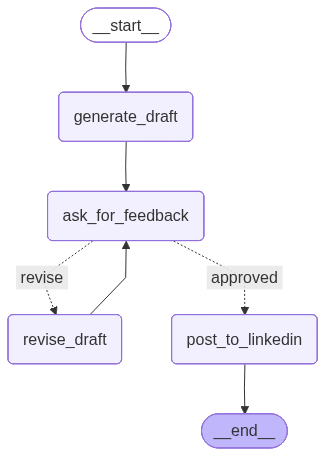

In [3]:
graph = build_workflow_graph()
graph

In [5]:
# -------------------------
# 6) Automatic run (CLI) — loops on interrupts until done
# -------------------------
def run_workflow_auto(initial_info: dict, thread_id: str = "linkedin_post_thread_1"):
    initial_state: PostState = {
        "info": initial_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None,
        "post_id": None,
        "post_error": None
    }

    graph = build_workflow_graph()
    config = {"configurable": {"thread_id": thread_id}}

    # Kick off graph execution (it will run until first interrupt)
    graph.invoke(initial_state, config=config)

    # Loop until no interrupts (workflow ended)
    while True:
        state = graph.get_state(config)
        interrupts = getattr(state, "interrupts", None) or []
        if not interrupts:
            break

        # There may be one interrupt (ask_for_feedback) — prompt user and resume
        for intr in interrupts:
            prompt = intr.value if hasattr(intr, "value") else str(intr)
            print(f"\n[HUMAN REVIEW PROMPT] {prompt}")
            # Collect human input from CLI
            answer = input("Enter feedback (or 'approve'): ").strip()
            # resume with mapping
            graph.invoke(Command(resume={intr.id: answer}), config=config)

    # Final state after workflow completion
    final_state = graph.get_state(config)
    print("\n=== Workflow finished. Final state ===")
    print(final_state)
    return final_state

# -------------------------
# 7) Example usage
# -------------------------
if __name__ == "__main__":
    example_info = {
        "topic": "Langgraph Agnetic AI Framework in AeroSpace Enginering",
        "key_points": "human-in-the-loop, agentic workflow, Use in aerospace negineering",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    run_workflow_auto(example_info)



=== AI Generated Draft ===
 🚀 Exciting news for aerospace engineers and AI enthusiasts alike!  
The new Agnetic AI framework is redefining how we tackle complex aerospace challenges by weaving human expertise directly into the decision loop. Its agentic workflow lets data scientists orchestrate autonomous agents that can reason, plan, and adapt—while still keeping a human touch for oversight, ethical judgment, and strategic tweaks.  

In practice, this means faster prototype validation, smarter resource allocation, and more resilient flight‑control logic—all powered by a system that learns from both machine insights and human intuition. If you’re looking to push the boundaries of what AI can do in the skies, this framework is a game‑changer worth exploring.

--- PAUSING FOR HUMAN REVIEW ---
Draft:
 🚀 Exciting news for aerospace engineers and AI enthusiasts alike!  
The new Agnetic AI framework is redefining how we tackle complex aerospace challenges by weaving human expertise directly